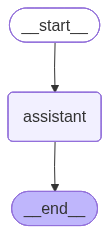

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful medical assistant.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm.invoke([sys_msg] + state["messages"])]}


from langgraph.graph import START, StateGraph
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_edge(START, "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))


In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0,
    api_key=OPENAI_API_KEY, # Optional, if not using environment variables
)

In [3]:
messages = [HumanMessage(content="Hi, Can you help me")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi, Can you help me
================================== Ai Message ==================================

Of course! How can I assist you today?
